# Quantum simulation of KdV

$$
\partial_t u + u\,\partial_x u + \delta\,\partial_{xxx} u = 0, \qquad u(0,x)=u_0(x),
$$

periodic BC on $[0,1]$, same Carleman + Crank-Nicolson + QSVT pathway as the Burgers notebook
(A. Setty, J. Phys. A 59, 185303 (2026)).

KdV's dispersion term is skew-symmetric, unlike Burgers' dissipative diffusion, so Carleman's usual
convergence guarantees (Liu et al., PNAS 118, e2026805118 (2021)) don't automatically transfer.
Checked directly: truncation order isn't the limiting factor here ($N_T=2$ vs. $N_T=3$ give
near-identical RMSE at $\delta=0.0625$) -- what actually limits accuracy at fixed $dt$ is dispersion
stiffness, which scales as $\delta/dx^3$. $\delta=0.0625$ keeps that stiffness in a regime where
Crank-Nicolson at $dt=0.1$ stays accurate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)
from scipy.interpolate import RectBivariateSpline

from kdv import KdV_Carlemann
from periodic_carleman import get_crank_nicolson_solver_qsvt_lcu
from qsvt_toolkit import compute_inverse_qsvt_angles
import resource_estimation as res_est


## Plot style

Same as the Burgers notebook: classical reference gray dashed, Dense QSVT blue, Pauli-LCU orange.


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from plot_style import set_style, COLORS
set_style()

CLASSICAL_COLOR = COLORS["classical"]
DENSE_COLOR = COLORS["blue"]
LCU_COLOR = COLORS["blue_lt"]


def time_ramp(n):
    """Sequential blue ramp, light to dark, for n timesteps."""
    return plt.cm.Blues(np.linspace(0.35, 0.95, n))


## 1. Carleman linearization (periodic, no forcing)

Same construction as Burgers, but no $F_0$ term (periodic BC, no external forcing, homogeneous
system) and $F_1$ is dispersion instead of diffusion. Same QSVT toolkit (`qsvt_toolkit.py`, `lcu.py`),
only the classical PDE data (`kdv.py`) differs. Time-marched with Crank-Nicolson, not implicit
Euler -- see the Burgers notebook's Section 1 for why (~20x fewer timesteps for the same accuracy,
checked classically).

## 2. Phase angles

Same `kappa=8` sequence as Burgers.


In [3]:
kappa = 8
phi_qsvt, s = compute_inverse_qsvt_angles(kappa, tolerance=1e-5)
len(phi_qsvt)


b=280, j0=51
[PolyOneOverX] minimum [-10.69067105] is at [-0.06701114]: normalizing
[PolyOneOverX] bounding to 0.9


560

## 3. Problem setup and resource estimates

$N=4$ (matches the variational method's grid for a direct comparison -- the challenge's
suggested KdV initial conditions, $\cos(4\pi x)$ and $\mathrm{sech}^2(40(x-1/2))$, both have
a degenerate (near-zero) discrete nonlinear term below $N=16$, so a custom initial condition
is used instead), $\delta=0.0625$, $N_T=2$.

In [4]:
N = 4
N_T = 2
delta = 0.0625
total_time = 0.3
dt = 0.1

u0_custom = np.array([0.0, -0.5, 1 / np.sqrt(2), 0.5])
u0_custom = u0_custom / np.linalg.norm(u0_custom)

kdv = KdV_Carlemann(N, N_T, total_time, delta, dt, ic=u0_custom)
x, dx = kdv.get_x_dx()

A_desired = kdv.get_I_m_Adt()
print(f"Shape of A : {A_desired.shape}")

Shape of A : (20, 20)


In [5]:
M, Dim, padded_dim = res_est._carleman_matrix_kdv(N=N, N_T=N_T, total_time=total_time, delta=delta, dt=dt, ic=u0_custom)
n_wires_dense = int(np.ceil(np.log2(M.shape[0]))) + 1
sigma_min = np.min(np.linalg.svd(M, compute_uv=False))

dense_stats = res_est.dense_layer_stats(M, n_wires_dense)
lcu_stats = res_est.lcu_layer_stats(M)
dense_stats["kappa_eff"] = dense_stats["norm"] / sigma_min
lcu_stats["kappa_eff"] = lcu_stats["norm"] / sigma_min

dense_proj = res_est.projector_layer_stats(n_wires_dense, n_ancilla=1)
lcu_proj = res_est.projector_layer_stats(lcu_stats["n_wires"], n_ancilla=lcu_stats["ancilla_qubits"])

n_angles = len(phi_qsvt)
dense_total = res_est.extrapolate_total(dense_stats, dense_proj, n_angles)
lcu_total = res_est.extrapolate_total(lcu_stats, lcu_proj, n_angles)

print(f"Carleman system: N={N}, N_T={N_T} -> Dim={Dim}, padded to {padded_dim}\n")
print(f"{'':14s}{'qubits':>8s}{'alpha':>10s}{'kappa_eff':>11s}{'gates (full circuit)':>24s}{'cx':>16s}{'depth':>16s}")
for name, layer, total in [("Dense", dense_stats, dense_total), ("Pauli-LCU", lcu_stats, lcu_total)]:
    print(f"{name:14s}{total['qubits']:>8d}{layer['norm']:>10.3f}{layer['kappa_eff']:>11.2f}"
          f"{total['gate_count']:>24,d}{total['two_qubit_gates']:>16,d}{total['depth']:>16,d}")


Carleman system: N=4, N_T=2 -> Dim=20, padded to 32

                qubits     alpha  kappa_eff    gates (full circuit)              cx           depth
Dense                6     3.836       4.02               2,610,531         996,697       1,967,681
Pauli-LCU           13     4.533       4.75             396,632,217     185,505,488     283,574,325


**Note on $\kappa_\mathrm{eff}$:** both encodings' effective condition number (dense $\approx 4.0$,
Pauli-LCU $\approx 4.8$) fit comfortably in `kappa=8`'s range.

## 4. Dense QSVT solver


In [6]:
y_store, RMSE_list, p_success_list = kdv.get_crank_nicolson_solver_qsvt(phi_qsvt, s)


Time step 1/3


Time step 2/3


Time step 3/3


## 5. Pauli-LCU solver


In [7]:
y_store_lcu, RMSE_list_lcu, p_success_list_lcu = get_crank_nicolson_solver_qsvt_lcu(kdv, phi_qsvt, s)


Time step 1/3


Time step 2/3


Time step 3/3


## 6. Classical reference

Exact, untruncated nonlinear ODE (RK45) -- isolates Carleman truncation and QSVT/LCU error from
spatial-discretization error.


In [8]:
y_ideal, rmse_ideal = kdv.get_crank_nicolson_solver()

y_ideal_euler, rmse_ideal_euler = kdv.get_implicit_solver()
print(f"Crank-Nicolson RMSE:   {np.round(rmse_ideal, 5)}")
print(f"Implicit-Euler RMSE:   {np.round(rmse_ideal_euler, 5)}  (same dt, for comparison)")


Crank-Nicolson RMSE:   [0.01318 0.0255  0.03774]
Implicit-Euler RMSE:   [0.09362 0.16515 0.21976]  (same dt, for comparison)


## 7. Results


### 7.1 Classical vs. quantum, timestep by timestep


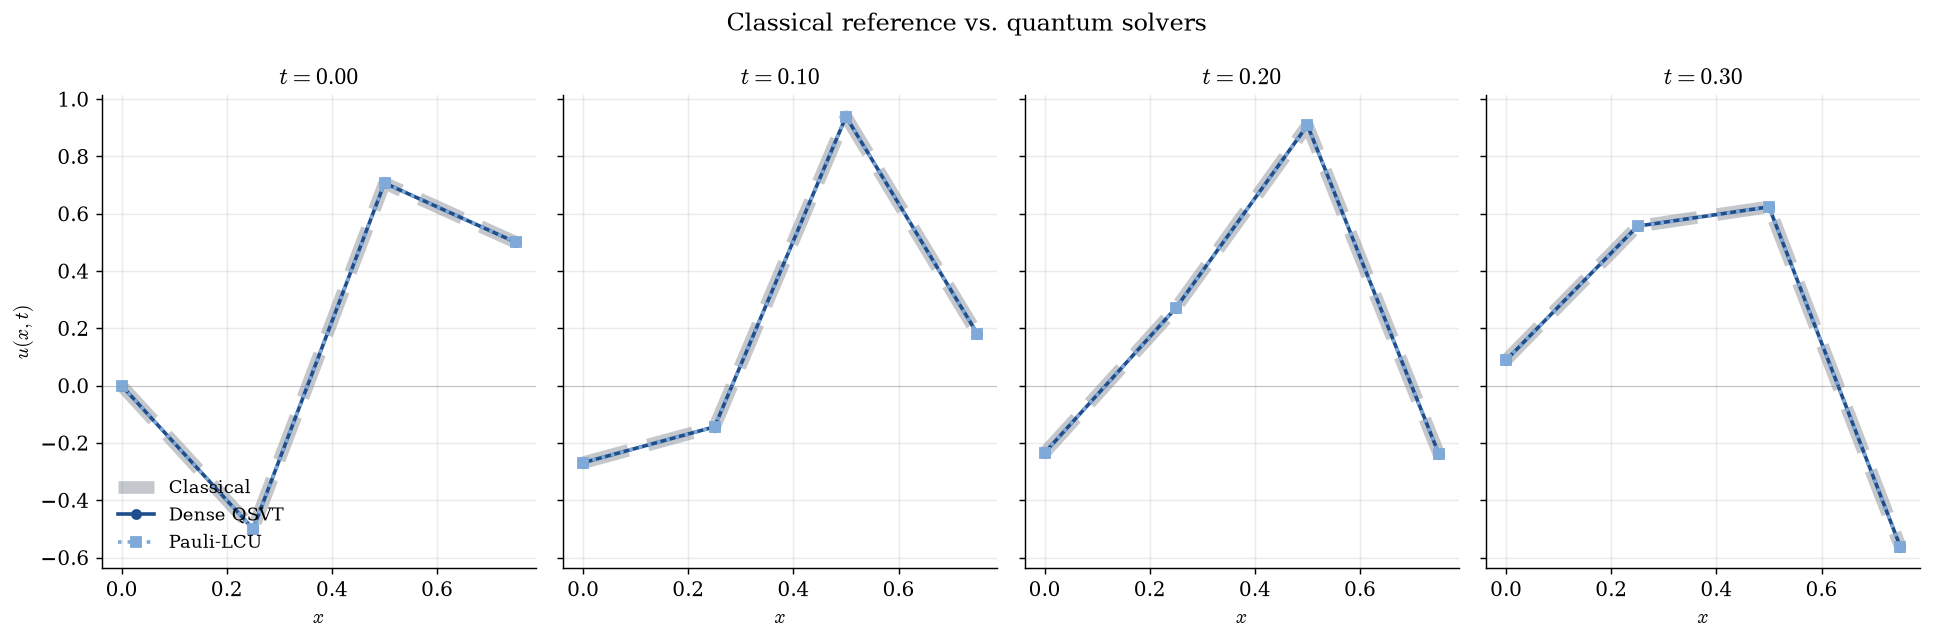

In [9]:
n_panels = len(y_ideal)
timesteps = np.arange(n_panels) * dt
fig, axes = plt.subplots(1, n_panels, figsize=(3.75 * n_panels, 5), sharey=True)
for i, ax in enumerate(axes):
    ax.plot(x, y_ideal[i], "--", color=CLASSICAL_COLOR, lw=7, alpha=0.5, label="Classical")
    ax.plot(x, y_store[i], "-", color=DENSE_COLOR, marker="o", label="Dense QSVT")
    ax.plot(x, y_store_lcu[i], ":", color=LCU_COLOR, marker="s", label="Pauli-LCU")
    ax.axhline(0, color=CLASSICAL_COLOR, lw=0.5, alpha=0.5)
    ax.set_title(f"$t = {timesteps[i]:.2f}$")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$u(x, t)$")
axes[0].legend(fontsize=10, loc="lower left")
fig.suptitle("Classical reference vs. quantum solvers")
fig.tight_layout()
fig.savefig("../prx_quantum/figures/fig_kdv_carleman.pdf", bbox_inches="tight")


### 7.2 Accuracy and success probability


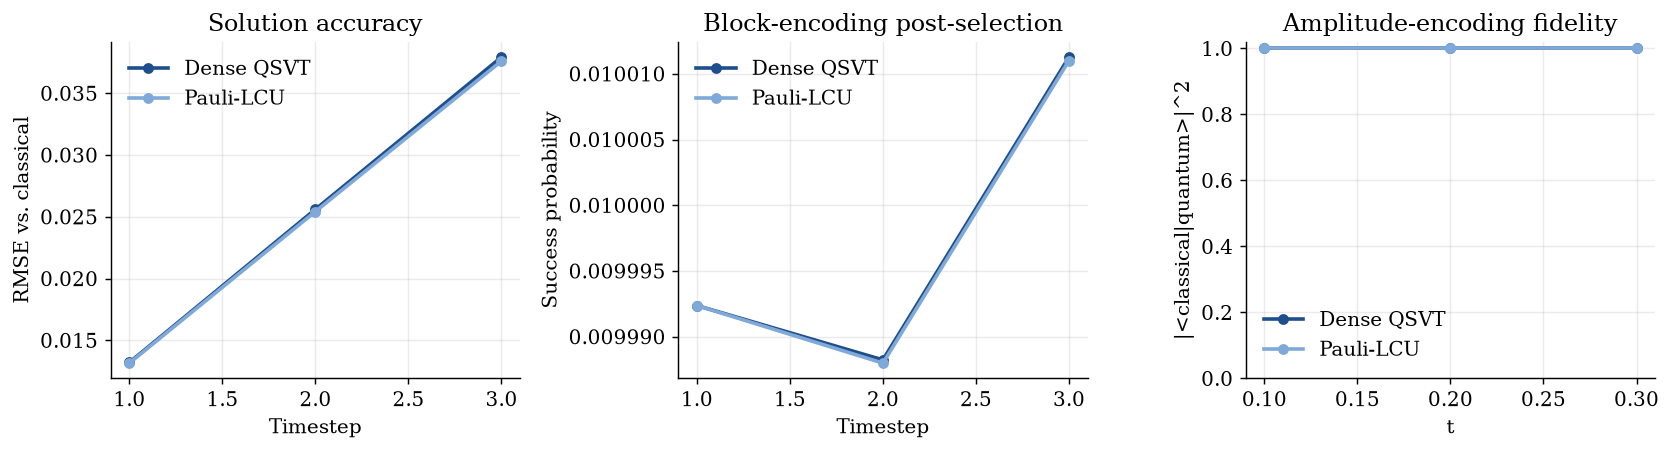

In [10]:
def fidelity(u_ref, u_test):
    u_ref = np.asarray(u_ref)
    u_test = np.asarray(u_test)
    nr, nt = np.linalg.norm(u_ref), np.linalg.norm(u_test)
    if nr == 0 or nt == 0:
        return np.nan
    return (np.dot(u_ref, u_test) / (nr * nt)) ** 2


fidelity_dense = [fidelity(y_ideal[i], y_store[i]) for i in range(1, len(y_ideal))]
fidelity_lcu = [fidelity(y_ideal[i], y_store_lcu[i]) for i in range(1, len(y_ideal))]
step_index = np.arange(1, len(RMSE_list) + 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

ax = axes[0]
ax.plot(step_index, RMSE_list, "o-", color=DENSE_COLOR, label="Dense QSVT")
ax.plot(step_index, RMSE_list_lcu, "o-", color=LCU_COLOR, label="Pauli-LCU")
ax.set_xlabel("Timestep")
ax.set_ylabel("RMSE vs. classical")
ax.set_title("Solution accuracy")
ax.legend(frameon=False)

ax = axes[1]
ax.plot(step_index, p_success_list, "o-", color=DENSE_COLOR, label="Dense QSVT")
ax.plot(step_index, p_success_list_lcu, "o-", color=LCU_COLOR, label="Pauli-LCU")
ax.set_xlabel("Timestep")
ax.set_ylabel("Success probability")
ax.set_title("Block-encoding post-selection")
ax.legend(frameon=False)

ax = axes[2]
ax.plot(timesteps[1:], fidelity_dense, "o-", color=DENSE_COLOR, label="Dense QSVT")
ax.plot(timesteps[1:], fidelity_lcu, "o-", color=LCU_COLOR, label="Pauli-LCU")
ax.set_xlabel("t")
ax.set_ylabel("|<classical|quantum>|^2")
ax.set_title("Amplitude-encoding fidelity")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower left")

fig.tight_layout()
fig.savefig("../prx_quantum/figures/fig_kdv_timemarching.pdf", bbox_inches="tight")


### 7.3 Resource comparison


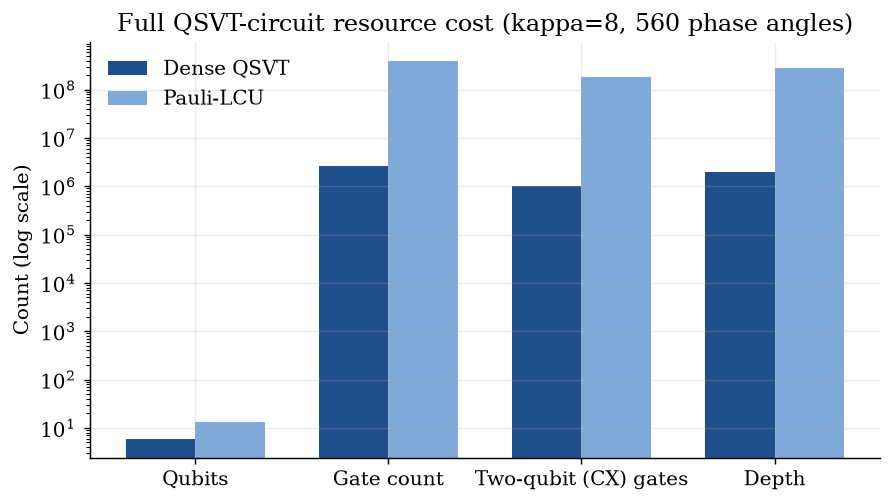

In [11]:
metrics = ["qubits", "gate_count", "two_qubit_gates", "depth"]
metric_labels = ["Qubits", "Gate count", "Two-qubit (CX) gates", "Depth"]
dense_vals = [dense_total[m] for m in metrics]
lcu_vals = [lcu_total[m] for m in metrics]

fig, ax = plt.subplots(figsize=(7, 4))
xpos = np.arange(len(metrics))
width = 0.36
ax.bar(xpos - width / 2, dense_vals, width, color=DENSE_COLOR, label="Dense QSVT")
ax.bar(xpos + width / 2, lcu_vals, width, color=LCU_COLOR, label="Pauli-LCU")
ax.set_yscale("log")
ax.set_xticks(xpos)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Full QSVT-circuit resource cost (kappa={kappa}, {n_angles} phase angles)")
ax.legend(frameon=False)
fig.tight_layout()
